# 2.1 — Why hedge, and what "good" means

> *"We are in the business of collecting the spread, not of predicting the weather."*
> — an options market-maker, explaining to a new quant why the desk hedges every evening

## The problem

Module 1 taught us to *describe* the risk. Now we must decide what to do with it, and the first honest
question is: **why hedge at all?** Hedging costs spread, impact, margin and roll (Chapter 1.3). A desk that
hedged nothing would save all of that. So there must be something we are buying with those costs.

This chapter answers three things:

1. What does the P&L of an *unhedged* market-making inventory look like — is it really that bad?
2. What objective function should a hedger optimise? ("Minimise variance" is a slogan; we derive when it
   is right.)
3. How do transaction costs change the answer — should we ever *under*-hedge on purpose?

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().resolve()
while not (_root / "gashedge").exists():
    _root = _root.parent
sys.path.insert(0, str(_root))

from datetime import date
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from gashedge import get_logger
from gashedge.plotting import setup_style

from gashedge.market_data import simulate_mm_inventory, simulate_hub_history
from gashedge.hedging import pnl_stats
from gashedge.plotting import plot_series, plot_pnl_distributions
setup_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
log = get_logger("ch2.1")
log.info("Environment ready")

2026-09-13 16:46:58.923 | INFO    | ch2.1 | Environment ready


## 1. Where the inventory comes from

A market-maker quotes a bid and an offer around fair value and earns the spread when both sides trade.
But fills do not arrive in matched pairs. Customers are net buyers for a few weeks (a cold forecast), then
net sellers (storage is full). The book's **inventory** — the net long or short left behind — therefore
*drifts*, and the drift is persistent. `simulate_mm_inventory` captures this with a Poisson number of
fills per day, each of random signed size, plus a slowly varying skew.

2026-09-13 16:46:58.928 | INFO    | gashedge.market_data | Simulated MM inventory: final 54 lots, max |inv| 165 lots


2026-09-13 16:46:58.930 | INFO    | gashedge.market_data | Simulated 250 days of hub history (crisis=False); TTF range 31.3-48.6


2026-09-13 16:46:58.985 | INFO    | ch2.1 | Inventory: mean 63 lots, max long 165, max short -31


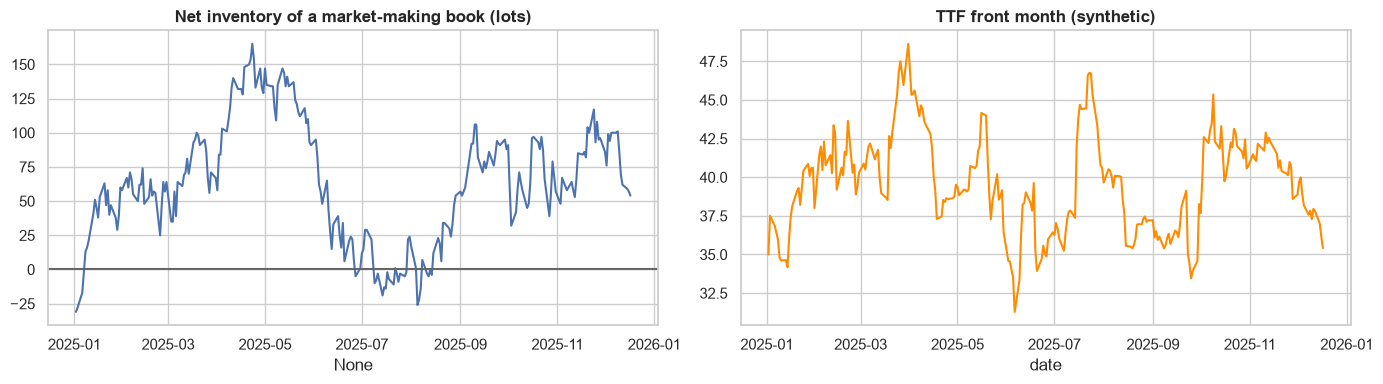

In [2]:
N_DAYS = 250
inv = simulate_mm_inventory(n_days=N_DAYS, fills_per_day=40, lot_std=2.0)
prices = simulate_hub_history(n_days=N_DAYS, start=date(2025, 1, 2), ttf0=35.0, seed=3).TTF
LOT_MWH = 730                                   # average hours per month; exact hours per contract in Ch.1.1
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(x=inv.index, y=inv.values, ax=axes[0]); axes[0].axhline(0, color="0.4"); axes[0].set_title("Net inventory of a market-making book (lots)")
sns.lineplot(x=prices.index, y=prices.values, ax=axes[1], color="darkorange"); axes[1].set_title("TTF front month (synthetic)")
plt.tight_layout()
log.info("Inventory: mean %.0f lots, max long %.0f, max short %.0f", inv.mean(), inv.max(), inv.min())

## 2. The unhedged P&L

Mark-to-market each day. With inventory $I_{t-1}$ lots carried into day $t$ and a price change $\Delta P_t$,

$$
\Pi_t^{\text{unhedged}} = I_{t-1}\cdot H\cdot \Delta P_t
\tag{2.1}
$$

(we ignore the spread income here — it is the *same* whether we hedge or not, so it does not affect the
decision). The result is what every MM desk head fears: a P&L that has nothing to do with how well the
desk made markets, and everything to do with which way gas went while they happened to be long.

2026-09-13 16:46:59.151 | INFO    | ch2.1 | Unhedged daily P&L std 69272 EUR vs daily spread income 2920 EUR: ratio 24x


,mean,std,min,q01,q99,total
name,,,,,,
unhedged inventory,-1551.0,69272.0,-282628.0,-201843.0,193128.0,-387742.0
spread income,2920.0,0.0,2920.0,2920.0,2920.0,730000.0


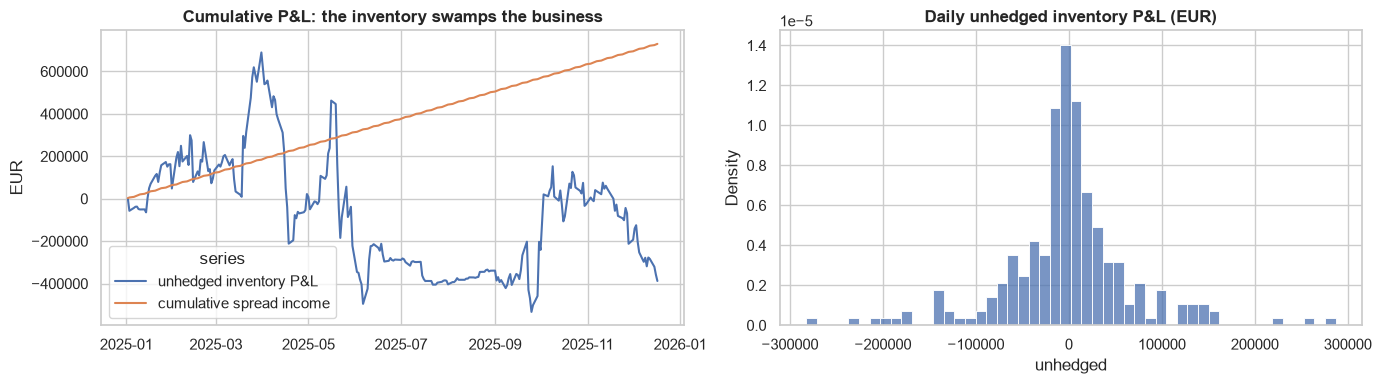

In [3]:
dP = prices.diff().fillna(0.0)
pnl_unhedged = (inv.shift(1).fillna(0.0) * LOT_MWH * dP).rename("unhedged")
spread_income = pd.Series(40 * 2.0 * 0.05 * LOT_MWH, index=inv.index).rename("spread income")  # ~40 fills x 2 lots x 5c captured edge per MWh
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_series(pd.DataFrame({"unhedged inventory P&L": pnl_unhedged.cumsum(), "cumulative spread income": spread_income.cumsum()}),
            title="Cumulative P&L: the inventory swamps the business", ylabel="EUR", ax=axes[0])
sns.histplot(pnl_unhedged, bins=50, ax=axes[1], stat="density"); axes[1].set_title("Daily unhedged inventory P&L (EUR)")
plt.tight_layout()
stats = pd.DataFrame([pnl_stats(pnl_unhedged, "unhedged inventory"), pnl_stats(spread_income, "spread income")]).set_index("name")
log.info("Unhedged daily P&L std %.0f EUR vs daily spread income %.0f EUR: ratio %.0fx", stats.loc["unhedged inventory", "std"],
         stats.loc["spread income", "mean"], stats.loc["unhedged inventory", "std"] / stats.loc["spread income", "mean"])
stats.round(0)

The daily *noise* of the inventory is tens of times the daily *income* of the business. A desk in this
state is not a market-maker; it is a directional gas fund that happens to also quote prices. Two real
reminders of where that ends:

* **Amaranth Advisors (2006)** lost about \$6.6 bn in a few weeks on natural-gas calendar spreads that had
  become far too large for the market's liquidity — the position was the risk, and when it had to be
  unwound the exit *was* the loss.
* Closer to home, every market-making desk that has been shut down was shut down for the inventory P&L,
  never for the spread P&L.

## 3. What objective? A mean–variance derivation

Suppose we hold $Q$ MWh of exposure $S$ and sell $hQ$ MWh of hedge instrument $F$, paying a proportional
transaction cost $c$ EUR per MWh traded. One-period P&L:

$$
\Pi = Q\,\Delta S - hQ\,\Delta F - c\,|h|\,Q
\tag{2.2}
$$

A risk-averse hedger with risk-aversion $\lambda$ maximises the *certainty equivalent*
$U = \mathbb{E}[\Pi] - \tfrac{\lambda}{2}\text{Var}(\Pi)$. Writing $\mu_S, \mu_F$ for expected changes and
$\sigma_S, \sigma_F, \rho$ for the second moments:

$$
U(h) = Q\mu_S - hQ\mu_F - c|h|Q \;-\; \frac{\lambda Q^2}{2}\left(\sigma_S^2 - 2h\rho\sigma_S\sigma_F + h^2\sigma_F^2\right)
\tag{2.3}
$$

Differentiate with respect to $h$ (for $h>0$) and set to zero:

$$
-Q\mu_F - cQ + \lambda Q^2\left(\rho\sigma_S\sigma_F - h\sigma_F^2\right) = 0
\;\;\Longrightarrow\;\;
h^{*} = \underbrace{\rho\frac{\sigma_S}{\sigma_F}}_{\text{min-variance}} \;-\; \underbrace{\frac{\mu_F + c}{\lambda Q \sigma_F^2}}_{\text{speculative + cost term}}
\tag{2.4}
$$

Read (2.4) slowly — it is the whole philosophy of hedging in one line:

* If futures are (near) **martingales**, $\mu_F \approx 0$: there is no expected gain from being short or
  long the hedge, so the *view* term vanishes and only variance matters. This is the standard
  assumption for a hedger who has no edge in direction — which is the honest position of a market-maker.
* Transaction costs **shrink the hedge toward zero**, by an amount that falls with position size $Q$
  and risk aversion $\lambda$. For big, risk-averse books the correction is negligible and
  $h^* \to \rho\sigma_S/\sigma_F$ — the *minimum-variance hedge ratio* of Chapter 1.4, now *derived*.
* For small positions the cost term can dominate: the optimal hedge is **zero**. That is not laziness; it
  is the mathematically correct origin of *hedging bands* (Chapter 2.5).

In [4]:
def cost_adjusted_ratio(rho, sigma_s, sigma_f, c, lam, Q, mu_f=0.0):
    h_mv = rho * sigma_s / sigma_f
    h = h_mv - (mu_f + c) / (lam * Q * sigma_f**2)
    return h_mv, max(h, 0.0)

rho, sigma_s, sigma_f = 0.96, 1.25, 1.20        # EUR/MWh daily, PEG vs TTF-like
c = 0.01                                        # 1 cent per MWh round-trip cost
lam = 1e-6                                      # risk aversion in 1/EUR
Qs = np.array([200, 500, 1_000, 2_000, 5_000, 20_000, 100_000])
table = pd.DataFrame({"Q_mwh": Qs})
table[["h_min_variance", "h_cost_adjusted"]] = [cost_adjusted_ratio(rho, sigma_s, sigma_f, c, lam, q) for q in Qs]
table["hedge_mwh"] = (table.h_cost_adjusted * table.Q_mwh).round(0)
log.info("Cost term (mu_F + c)/(lambda Q sigma_F^2) shrinks the hedge: for Q=500 MWh h=%.2f, for Q=100k MWh h=%.3f",
         table.h_cost_adjusted.iloc[1], table.h_cost_adjusted.iloc[-1])
table.round(3)

2026-09-13 16:46:59.281 | INFO    | ch2.1 | Cost term (mu_F + c)/(lambda Q sigma_F^2) shrinks the hedge: for Q=500 MWh h=0.00, for Q=100k MWh h=0.931


,Q_mwh,h_min_variance,h_cost_adjusted,hedge_mwh
0,200,1.0,0.000,0.0
1,500,1.0,0.000,0.0
2,1000,1.0,0.000,0.0
3,2000,1.0,0.000,0.0
4,5000,1.0,0.000,0.0
5,20000,1.0,0.653,13056.0
6,100000,1.0,0.931,93056.0


## 4. Variance is not the only sensible objective — but it is the right *default*

Alternatives you will hear about, and why we keep variance as the workhorse:

| Objective | When it is better | Cost |
|---|---|---|
| Minimise **variance** | you have no directional view, P&L roughly symmetric | ignores fat tails |
| Minimise **VaR / Expected Shortfall** | tail losses are what gets you fired; fat-tailed data | needs many more observations; unstable estimates |
| Maximise **Sharpe of hedged book** | you *do* have a view (e.g. basis mean reversion) | you are now a prop trader |
| Minimise **cost s.t. risk limit** | the practical formulation on most desks | needs a well-defined limit (Chapter 3.4) |

For linear instruments with roughly elliptical returns, the variance-minimising hedge is also the
VaR-minimising hedge (both scale with $\sigma$), so the default loses little. Where it fails is when the
residual is *skewed* — e.g. a basis that mostly sleeps but occasionally blows out one way (Chapter 1.5).
We revisit that in Chapter 3.4.

## 5. Where this leaves us

A market-maker hedges because inventory P&L swamps spread income; the hedge should minimise variance
unless the desk has a genuine directional edge; costs justify *not* hedging tiny positions. In symbols:
$h^* \approx \rho\sigma_S/\sigma_F$ with a cost haircut.

**Pitfall that leads to the next chapter:** equation (2.4) assumes a single generic instrument $F$.
In reality we choose between futures, cleared swaps, bilateral forwards, and simply offsetting in a
neighbouring month — each with different $\rho$, different $c$, and, crucially, *different cash-flow
timing*. Chapter 2.2 lays out the menu.

### Check your understanding

Work these on paper (or in a scratch cell) *before* expanding the answers.

**Q1.** A desk holds 20,000 MWh of an exposure with $\sigma_S = 1.25$, hedges with an instrument with $\sigma_F = 1.20$, $\rho = 0.96$, cost $c = 0.02$ EUR/MWh, risk aversion $\lambda = 2\times 10^{-6}$ per EUR, and $\mu_F = 0$. Compute the minimum-variance and cost-adjusted hedge ratios. Then repeat for a 400 MWh position.

<details><summary><i>Answer 1</i></summary>

$h_{mv} = 0.96 \times 1.25/1.20 = \mathbf{1.000}$. Cost term $= c/(\lambda Q \sigma_F^2) = 0.02 / (2\times10^{-6} \times 20{,}000 \times 1.44) = 0.02/0.0576 = 0.347$ → $h^* = 1.000 - 0.347 = \mathbf{0.653}$. For $Q = 400$: cost term $= 0.02/(2\times10^{-6}\times400\times1.44) = 0.02/0.001152 = 17.4 \gg 1$ → $h^* = \mathbf{0}$: do not hedge 400 MWh at these costs. (With $\lambda$ this small the desk is quite risk-tolerant; a more risk-averse $\lambda = 10^{-4}$ would give a cost term of 0.007 for 20,000 MWh — essentially full hedge.)

</details>

**Q2.** Explain in words why the assumption $\mu_F = 0$ is *both* reasonable for a market-maker and dangerous if applied to a seasonal spread hedge (Chapter 1.2).

<details><summary><i>Answer 2</i></summary>

Reasonable: a market-maker has no informational edge on the direction of gas prices; futures prices are close to martingales over a day, and any risk premium is tiny relative to daily volatility, so pretending $\mu_F = 0$ costs almost nothing in expected P&L and avoids turning the hedge into a bet. Dangerous for seasonal spreads: a long-winter/short-summer position has a *structurally negative expected drift* in some regimes (the spread is capped above by storage cost of carry and tends to be pulled toward it — Chapter 1.2) plus a fat left tail. Setting $\mu_F=0$ there ignores a predictable cost of carry and an asymmetric payoff; the hedge ratio must include the expected roll/carry, which is exactly what the $\mu_F$ term in (2.4) is for.

</details>

**Q3.** In the simulation, daily inventory P&L standard deviation is dozens of times the daily spread income. Suppose the desk instead hedged perfectly at the close each day. Which risk *remains*, and how would you size it?

<details><summary><i>Answer 3</i></summary>

The **intraday** inventory risk remains: between fills and the closing hedge the book is exposed for hours. Its size is $\sigma_{\text{intraday}} \approx \sigma_{\text{daily}} \times \sqrt{\text{fraction of day exposed}} \times$ average intraday inventory, roughly $\sigma_d\sqrt{1/2}$ times a typical mid-day inventory if inventory builds linearly. If daily $\sigma$ of the unhedged book is $X$, an end-of-day hedger still carries on the order of $0.3$–$0.5X$ — which is why liquid desks hedge continuously with bands (Chapter 2.5), not once a day.

</details>

**Q4.** Amaranth's natural-gas positions were reportedly a large multiple of the open interest in some contract months. Using Chapter 1.3's cost model, explain why the *unwind* was the loss, and what that implies for a hedging engine's position limits.

<details><summary><i>Answer 4</i></summary>

Impact cost scales as $\sqrt{n/D}$ per unit and hence as $n^{3/2}$ in total (eq. 1.8). When $n$ is a multiple of daily volume, the impact term dwarfs the half-spread: the act of selling moves the price against you by far more than the theoretical value you are selling. Amaranth's mark-to-market was fine until it *had* to trade; the price it received was the price of everyone knowing it had to trade. Implication: hedging engine limits should be expressed in **days of volume** (eq. 1.9), not in lots or euros, and residual/proxy positions that cannot be exited within a small number of days must be capped regardless of how good the hedge ratio looks.

</details>


---
◀ [Previous](../module1_market_structure/05_hubs_and_basis.ipynb) · [Contents](../00_introduction.ipynb) · [Next ▶](02_instrument_menu.ipynb)